# Task 4 — Neo4j Demo Notebook

This notebook demonstrates:
1. Connecting to Neo4j Aura (or local) using environment variables.
2. Running the **two required queries** and saving PNG charts to `de-ass/docs/`.

**Expected labels in assignment**: `Country`, `Event`, `Cases`, `Deaths`, `Recovered`, `Tests`, `Active`.

**Environment variables required**:
- `NEO4J_URI`, `NEO4J_USER`, `NEO4J_PASS`, `NEO4J_DATABASE` (optional)
- `TASK2_PARQUET` if you plan to run the loader.

In [5]:
# --- Setup & helpers ---
from __future__ import annotations
import os, sys
from pathlib import Path
from typing import Any

import pandas as pd
from neo4j import GraphDatabase

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASS = os.getenv("NEO4J_PASS", "neo4j")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

# Find and add the classes directory to sys.path
classes_dir = None
for root in [Path.cwd(), *Path.cwd().parents]:
    for cand in (root / "de-ass" / "classes", root / "classes"):
        if cand.exists():
            classes_dir = cand
            break
    if classes_dir:
        break

if not classes_dir:
    raise FileNotFoundError("Couldn't find a 'classes' folder from this notebook location.")

sys.path.insert(0, str(classes_dir))
print("Using classes dir:", classes_dir)

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
print("Connected to:", NEO4J_URI, "db=", NEO4J_DATABASE)

def run(cypher: str, **params) -> list[dict[str, Any]]:
    with driver.session(database=NEO4J_DATABASE) as s:
        return [r.data() for r in s.run(cypher, **params)]

def df(cypher: str, **params) -> pd.DataFrame:
    rows = run(cypher, **params)
    return pd.DataFrame(rows)


Using classes dir: /home/student/de-ass/classes
Connected to: neo4j+s://338a7245.databases.neo4j.io db= neo4j


## Inspect current labels & counts
Labels exist and Nodes each label has.

In [6]:
# --- Configure Aura connection in *this* kernel ---
import os

cfg = {
    "NEO4J_URI": "neo4j+s://338a7245.databases.neo4j.io",
    "NEO4J_USER": "neo4j",
    "NEO4J_PASS": "hZhDOA0QDLBsIJ1Xw6qhgiMZ3yHqH5wwqd02iZxY23k",
    "NEO4J_DATABASE": "neo4j",
}
os.environ.update(cfg)

# If a previous driver exists from earlier cells, close it to avoid stale settings
try:
    driver.close()  # type: ignore
except Exception:
    pass

from neo4j import GraphDatabase
driver = GraphDatabase.driver(cfg["NEO4J_URI"], auth=(cfg["NEO4J_USER"], cfg["NEO4J_PASS"]))
print("Connected to:", cfg["NEO4J_URI"], "db=", cfg["NEO4J_DATABASE"])

def run(cypher: str, **params):
    with driver.session(database=cfg["NEO4J_DATABASE"]) as s:
        return [r.data() for r in s.run(cypher, **params)]

import pandas as pd
def df(cypher: str, **params) -> pd.DataFrame:
    return pd.DataFrame(run(cypher, **params))

# Quick sanity check
print(run("RETURN 1 AS ok"))


Connected to: neo4j+s://338a7245.databases.neo4j.io db= neo4j
[{'ok': 1}]


In [7]:
labels_counts = df(
    """
    MATCH (n)
    UNWIND labels(n) AS l
    RETURN l AS label, count(*) AS count
    ORDER BY count DESC
    """
)
labels_counts

,label,count
0,Deaths,420
1,Recovered,420
2,Tests,420
3,Active,420
4,Event,420
5,Cases,420
6,Country,210


## Run the two required queries and plot PNGs
This reuses your `task4_neo4j_queries.py` class and saves charts to `de-ass/docs/`.

Using date: 2025-08-23
[OK] Saved chart → /home/student/de-ass/docs/task4_top_cases_per_million.png

Query 1 — Top Cases per Million
Date: 2025-08-23   Model: Event-centered

           #               Country     Continent   Population   CasesTotal   TodayCases CasesPerMillion    CpmSource
           1                Brunei          Asia      445,431      343,720            1      771,657.11     reported
           2            San Marino        Europe       34,085       26,186            1      768,255.83     reported
           3         Faroe Islands        Europe       49,233       34,659            1      703,979.04     reported
           4               Austria        Europe    9,066,710    6,081,291            4      670,727.42     reported
           5              Slovenia        Europe    2,078,034    1,356,546            0      652,802.60     reported
           6               Andorra        Europe       77,463       48,016            1      619,857.22     reported
      

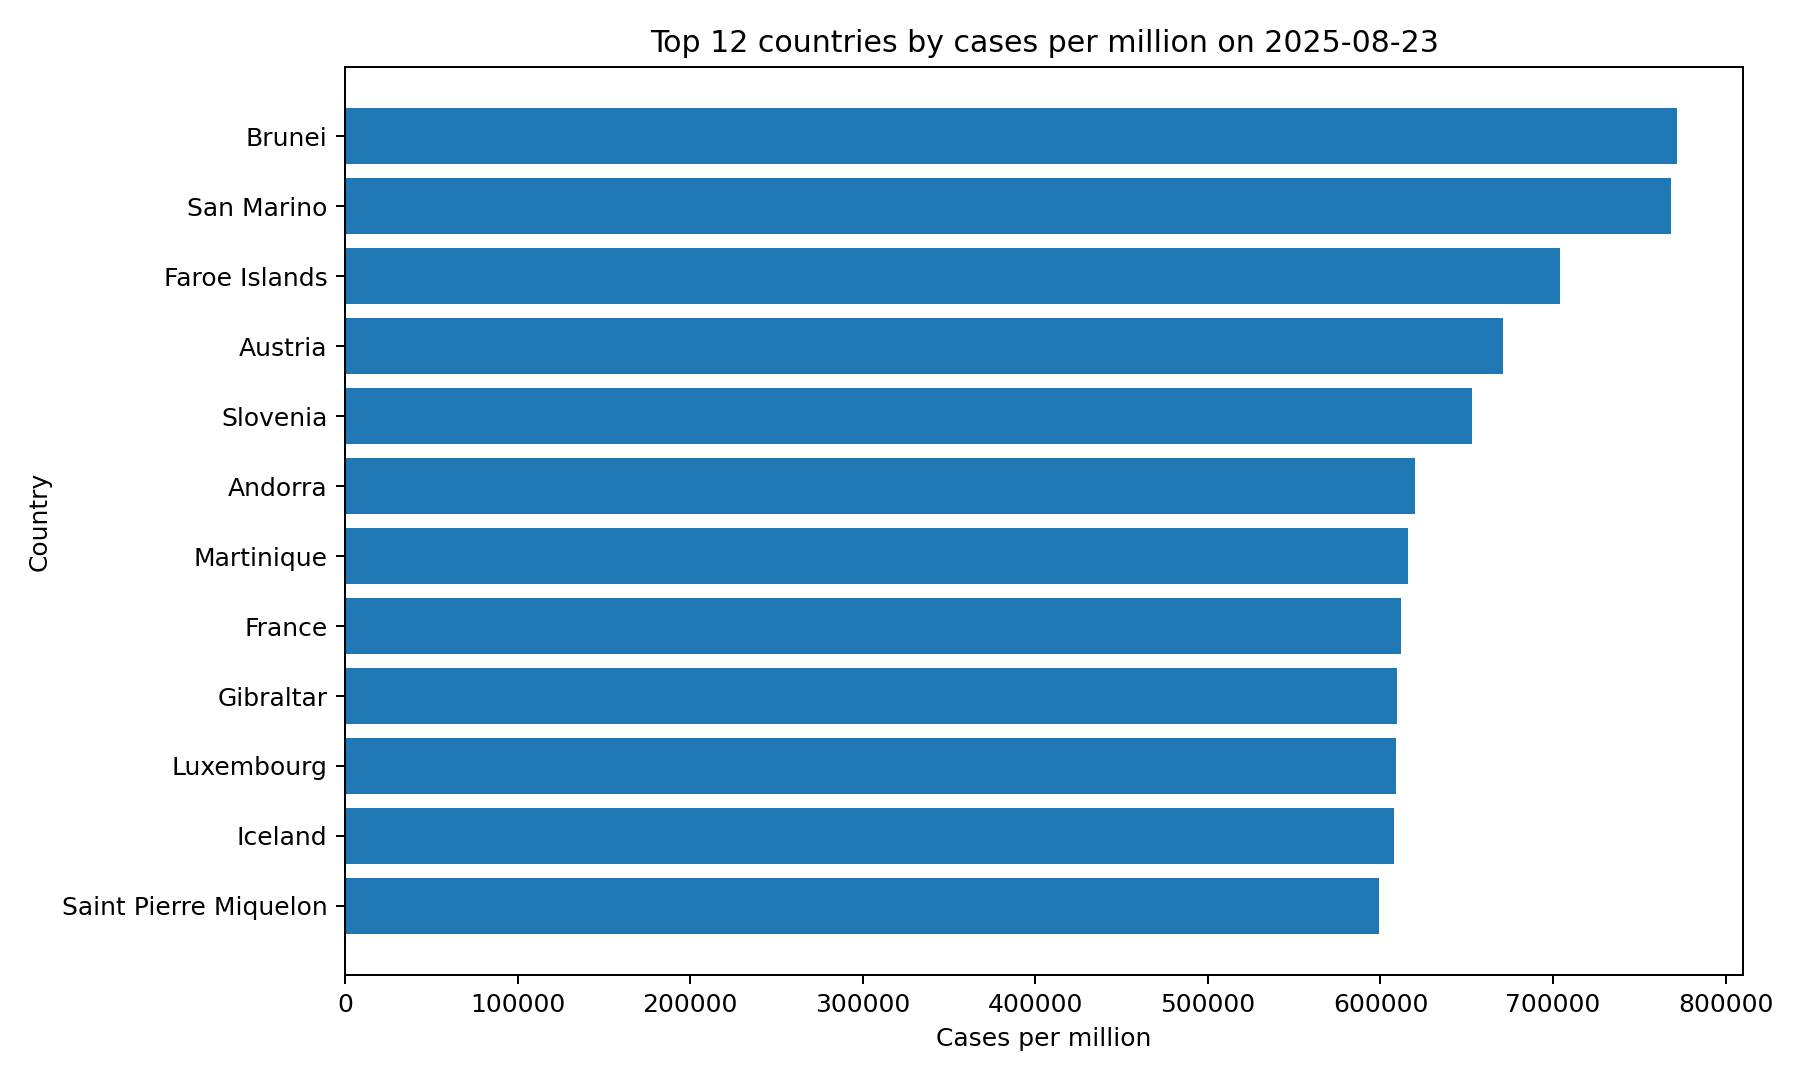

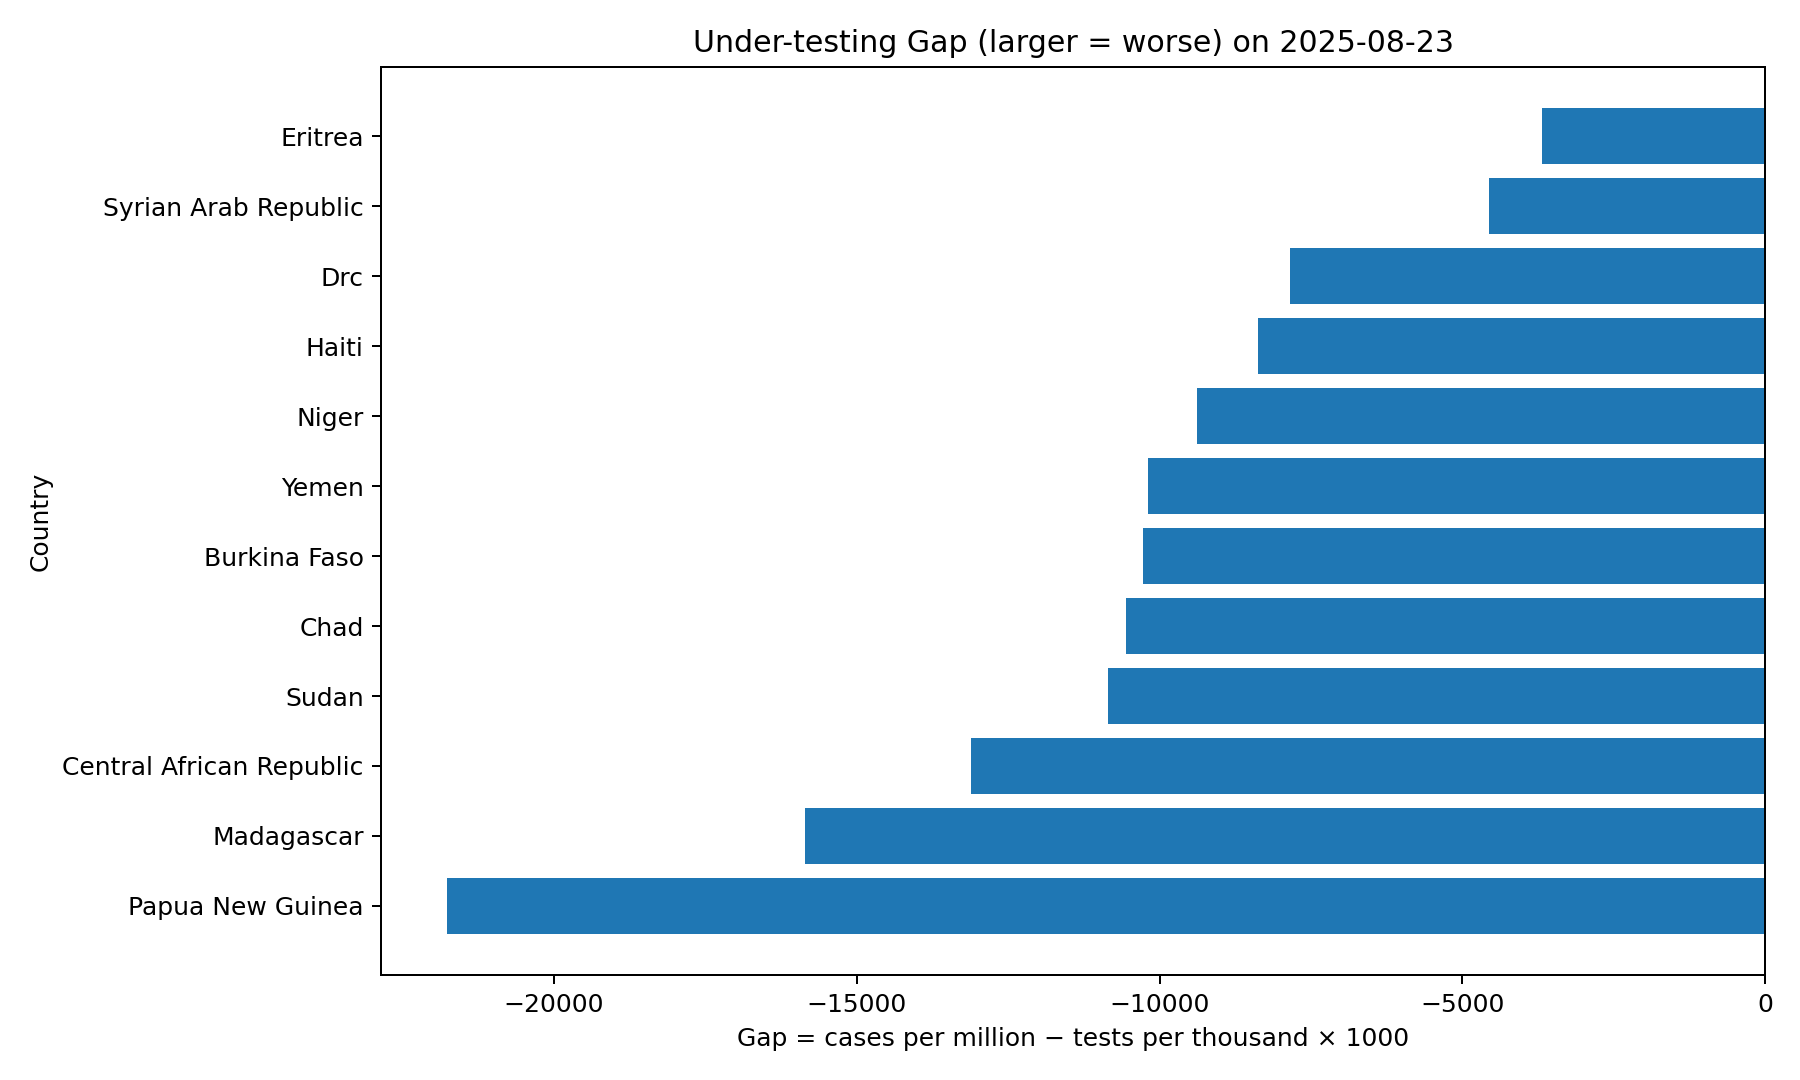

In [9]:
import sys
sys.path.append('classes')
from task4_neo4j_queries import Neo4jQueries
import matplotlib.pyplot as plt
from IPython.display import Image, display

# --- Pick a date (use TASK4_DATE if set; else latest in graph) ---
DATE = os.getenv("TASK4_DATE", "").strip()
if not DATE:
    drv = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
    with drv.session(database=NEO4J_DATABASE) as s:
        rec = s.run("MATCH (e:Event) RETURN e.event_date AS d ORDER BY d DESC LIMIT 1").single()
    drv.close()
    if not rec or not rec["d"]:
        raise SystemExit("No Event dates found in Neo4j. Load Task 4 data first.")
    DATE = str(rec["d"])
print("Using date:", DATE)

q = Neo4jQueries(NEO4J_URI, NEO4J_USER, NEO4J_PASS, database=NEO4J_DATABASE)
try:
    out1 = q.query1_cases_per_million(DATE, limit=12)
    out2 = q.query2_under_testing_gap(DATE, limit=12)
finally:
    q.close()

print("Saved:", out1)
print("Saved:", out2)
display(Image(filename=str(out1)))
display(Image(filename=str(out2)))
